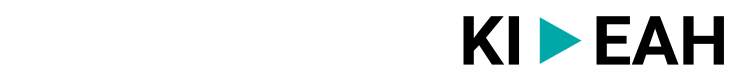

**Baustein:** Clustering  $\rightarrow$ **Subbaustein:** Grundlagen, Übersicht, Partitionierendes und Hierarchisches Clustering $\rightarrow$ **Codebeispiele**

**Version:** 1.0, **Lizenz:** <a rel="license" href="http://creativecommons.org/licenses/by-nc-nd/4.0/">CC BY-NC-ND 4.0</a>

***

# Clustering: K-Means und AHC

Folgende Problemstellung soll mit Hilfe des Clustering Algorithmuses K-Means diskutiert und gelöst werden: 

Gegeben sei ein Datensatz bestehend aus 2818 Datenpunkten, die in der Datei **krankheitscluster.csv** gespeichert sind. Jeder Datenpunkt besteht aus einem Floatwert für die *Intensität der Kopfschmerzen* (angegeben als *headache*), einem Floatwert für *Intensität der Gliederschmerzen* (angegeben als *melalgia*) und einem Integer (angegeben als *class*), der angibt zu welchem Cluster der Datenpunkt gehört. Bei einem realen Clusteringproblem ist letzteres nicht gegeben. Aber um die Effizienz des Algorithmus zu evaluieren nutzen wir diesen Werte als Vergleichswert (Ground Truth).


## Schritt 1: Importieren aller notewendigen Bibliotheken
---

In [1]:
%load_ext autoreload
%autoreload 2

# Eine Bibliothek zur effizienten Anwendung mathematischer Operationen auf Array
import numpy as np
# Pandas ist ein schnelles, leistungsstarkes, flexibles und benutzerfreundliches Open-Source-Tool zur Datenanalyse und -manipulation.
import pandas as pd
# Zur Erstellung statischer, animierter und interaktiver Visualisierungen
import matplotlib.pyplot as plt
# Datenvisualisierung basierend auf matplotlib
import seaborn as sns
# Bibliothek für die Datenanalyse
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples
from sklearn.metrics import rand_score
# Stellt Algorithmen für die das wissenschaftliche Rechnen bereit
from scipy.cluster.hierarchy import dendrogram
# selbst definierte .py files (siehe Ordner "utils")
from utils.Utils import WidgetsKMeans
from utils.Utils import get_linkage_matrix

import warnings
warnings.filterwarnings('ignore')

## Schritt 2: Lesen des Datensatzes
---
In diesem Schritt soll der Datensatz, der als CSV-Datei vorliegt gelesen und als DataFrame bereitgestellt werden. Dabei sollen vorerst Metadaten, wie die Anzahl der Datenpunkte, herausgegeben werden.

### Angaben zum Datensatz:
Jeder Zeile in der CSV-Datei gibt einen Datenpunkt wieder, mit Ausnahme der ersten Zeile. Diese beschreibt beschreibt die einzelnen Werte eines jeden Datenpunktes. Die ersten 4 Zeilen des Datensatzes *krankheitscluster.csv* sehen wie folgt aus:<br />

headache,melalgia,class<br />
4.3, 49.1, 0<br />
20.8, 50.7, 0<br />
7.0, 47.5, 0<br />

Formatiert sieht der Auszug folgendermaßen aus:

| headache | melalgia | class |
|---|---|---|
| 4.3 | 49.1 | 0 |
| 20.8 | 50.7 | 0 |
| 7.0 | 47.5 | 0 |

Daraus lässt sich nun ableiten, dass dieser Datensatz drei Features besitzt (headache, melalgia, class). Jedes Feature wird durch eine Spalte im Datensatz ausgedrückt. Jeder Datenpunkt hingegen wird durch eine Reihe ausgedrückt und besteht aus drei Instanzen der oben genannten Features, die durch Kommata separiert werden, d.h. das Komma dient als **Delimiter**. Somit besteht der erste Datenpunkt aus dem 3-Tupel (4.3, 49.1, 0).

Folgende Einschränkungen gelten pro Datenpunkt $x$:
$$
x\in [0,100]\times[0,100]\times\{0,1,2\}
$$

In [2]:
# Angabe des relativen Pfades der CSV-Datei
input_file = "datasets/krankheitscluster.csv"
# Erstellung des DataFrames; Hierbei wird Zeile 0 durch die Angabe "header = 0" als Zeile definiert, 
# die die Featurenamen und den Anfang der Daten angibt
df = pd.read_csv(input_file, header = 0)
# Gibt die ersten n Datenpunkte des DataFrames zurück
df.head(n=5)

,headache,melalgia,class
0,4.3,49.1,0
1,20.8,50.7,0
2,7.0,47.5,0
3,15.3,54.0,0
4,17.0,50.2,0


In [3]:
# Gibt die Namen der Features zurück.
df.columns

Index(['headache', 'melalgia', 'class'], dtype='object')

In [4]:
# Folgende wichtige Informationen werden zurückgegeben:
# (1) Anzahl der Einträge
# (2) Anzahl, Namen und Typen der Features
# (3) Anzahl der Werte pro Feature, die nicht Null sind
# (4) Speicherverbrauch
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2818 entries, 0 to 2817
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   headache  2818 non-null   float64
 1   melalgia  2818 non-null   float64
 2   class     2818 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 66.2 KB


In [5]:
# Gibt statistische Informationen über den Datensatz zurück.
df.describe()

,headache,melalgia,class
count,2818.000000,2818.000000,2818.000000
mean,49.290596,50.602342,0.979773
std,23.431021,19.478749,0.843831
min,0.000000,0.000000,0.000000
25%,26.225000,34.200000,0.000000
50%,51.750000,51.100000,1.000000
75%,70.300000,66.875000,2.000000
max,100.000000,100.000000,2.000000


## Schritt 3: Visualisierung des Datensatzes
---

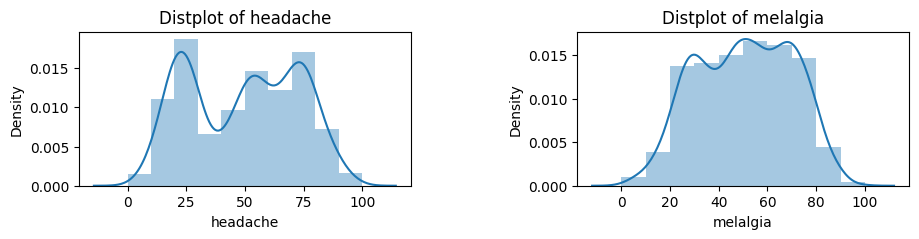

In [6]:
# Plotting von statistischen Informationen über den Datensatz.
# Hier wird für jedes Feature angegeben wie oft bestimmt Werte auftreten (normierte Angabe). Die Histogramme sind auf fünf Bins quantisiert,
# sodass z.B. Werte, die ungefähr im Intervall [0, 20] liegen, einem Bin im Histogramm zugeordnet werden.
plt.figure(1 , figsize = (30 , 2))
n = 0 
for x in ["headache", "melalgia"]:
    n += 1
    plt.subplot(1 , 5 , n)
    plt.subplots_adjust(hspace = 0.5 , wspace = 0.5)
    sns.distplot(df[x] , bins = 10)
    plt.title('Distplot of {}'.format(x))
plt.show()

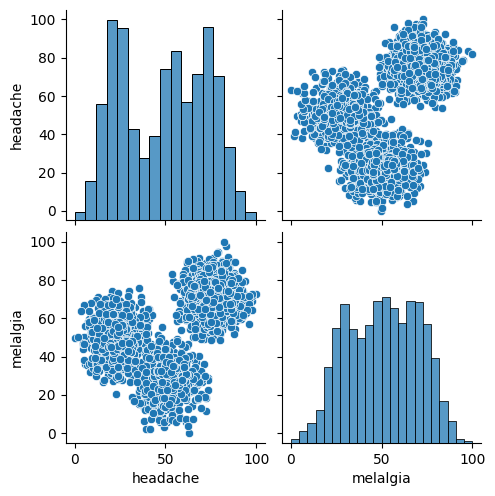

In [7]:
# Hier werden die Beziehung sämtlicher Features paarweise geplottet (Plots außerhalb der Diagonalen).
# Die diagonale Plot zeigen jeweils die marignalen Verteilungen eines Features, d.h. wie oft treten gewisse Ausprägungen eines Features
# auf, vergleichbar mit dem Plot zuvor.
sns.pairplot(df, vars = ["headache", "melalgia"])

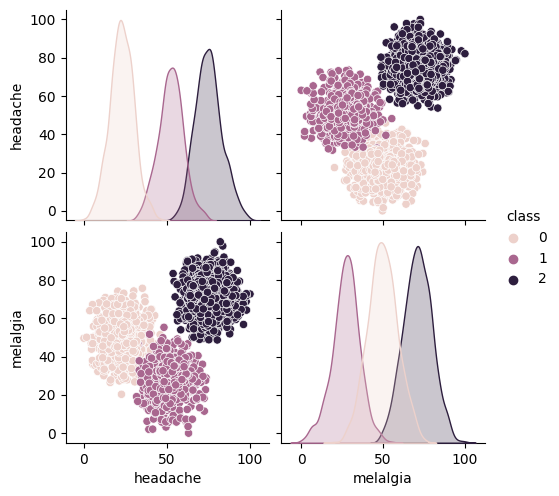

In [8]:
# Da unser Datensatz bereits die Clusterzugehörigkeiten beinhaltet, kann man anhand dieses Features die Datenpunkte
# die Clusterzugehörigkeit plotten. Auf diese Weise färben sich die Datenpunkte entsprechend der Cluster. Die Marginalverteilungen,
# die zuvor als Histogramme angezeigt wurden, sind nun kontinuierliche Marginalverteilungen der einzelnen Cluster.
sns.pairplot(df, vars = ["headache", "melalgia"], hue = 'class')

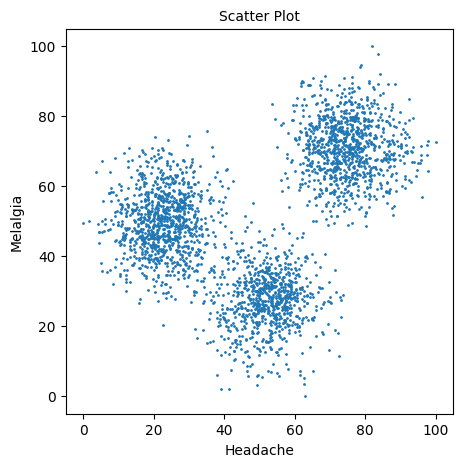

In [9]:
# Nun erzeugen wir ein Streudiagramm (engl. Scatter Plot) der ausgewählten Features und benennen entsprechend die Axen.
plt.figure(1 , figsize = (5 , 5))
plt.title('Scatter Plot', fontsize = 10)
#plt.xlabel('Intensität Kopfschmerzen')
#plt.ylabel('Intensität Gliederschmerzen')
plt.xlabel('Headache'), plt.ylabel('Melalgia')
plt.scatter( x = 'headache', y = 'melalgia', data = df, s = 1)
plt.show()

## Schritt 4: Bestimmung der Anzahl der Cluster K
---
Ein Hyperparameter des K-Means ist die Anzahl der Cluster. Diese werden vom Algorithmus nicht bestimmt, sondern müssen vom Nutzer angegeben werden. Dies kann man machen, indem man sich den Datensatz plottet und schaut, ob sich die Datensätze visuell trennen lassen. In unserem Beispiel ist dies möglich und es ergibt sich $K=3$. Problematisch wird es erst, wenn die Anzahl der Features größer als drei ist, denn dann lassen sich die Datenpunkte nicht mehr visualisieren. Eine weitere Möglichkeit ist die Bestimmung von $K$ aufgrund von Expertenwissen. Liegt aber beides nicht vor, muss die Anzahl anders bestimmt werden. Hierfür gibt es die folgenden zwei Verfahren:
- **Ellbogen-Methode**: <br />Hierbei wir die Summe der quadratische Abweichungen (Sum of Squared Distances - SSD) für verschiedene Anzahlen von Clustern berechnet und graphisch dargestellt. Der Punkt auf der Graphik, an dem der SSD-Abfall abflacht und eine Art Ellbogen bildet, wird als optimaler Punkt für die Anzahl der Cluster betrachtet.
- **Silhouetten-Methode**: <br />Sie berechnet für jeden Datenpunkt eine Silhouettenkoeffizienten, der die Ähnlichkeit innerhalb des eigenen Clusters im Vergleich zu den benachbarten Clustern misst. Ein hoher Silhouettenkoeffizient (nahe 1) zeigt an, dass der Datenpunkt gut seinem eigenen Cluster zugeordnet ist und sich gut von den anderen Clustern unterscheidet. Ein niedriger Silhouettenkoeffizient (nahe -1) deutet auf eine schlechte Clusterbildung hin. Die durchschnittliche Silhouettenkoeffizienten aller Datenpunkte wird verwendet, um die Qualität des Clustering-Ergebnisses zu bewerten, wobei ein höherer Durchschnittswert auf eine bessere Clusterbildung hinweist.

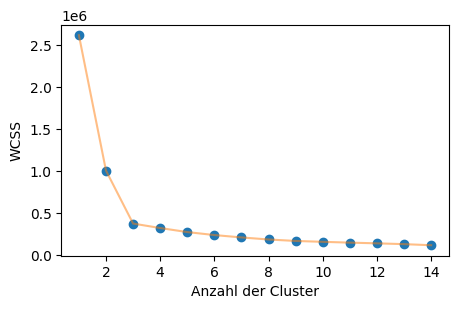

In [10]:
# Anwendung der Ellbogen-Methode für 1 bis 15 Cluster:
# Der K-Means Algorithmus wird für 1 bis 15 Cluster ausgeführt. Für jede Iteration wird die Summe der Quadratischen Distanzen zum nähersten
# Cluster berechnet (engl. Within Cluster Sum of Squares (WCSS)). Anhand des Plots lässt sich unsere Annahme von drei Clustern bestätigen. Die Parameter der K-Means 
# Algorithmuses aus der scikit-learn Bibliothek werden in Schritt 5 näher erläutert.
X1 = df[['headache' , 'melalgia']].iloc[: , :].values
inertia = []
for n in range(1 , 15):
    algorithm = (KMeans(n_clusters = n,
                        init='random', 
                        n_init = 1 ,
                        max_iter=300, 
                        tol=0.0001,  
                        random_state= 111 , 
                        algorithm='lloyd') )
    algorithm.fit(X1)
    inertia.append(algorithm.inertia_)

plt.figure(1 , figsize = (5 ,3))
plt.plot(np.arange(1 , 15) , inertia , 'o')
plt.plot(np.arange(1 , 15) , inertia , '-' , alpha = 0.5)
plt.xlabel('Anzahl der Cluster') , plt.ylabel('WCSS')
plt.show()

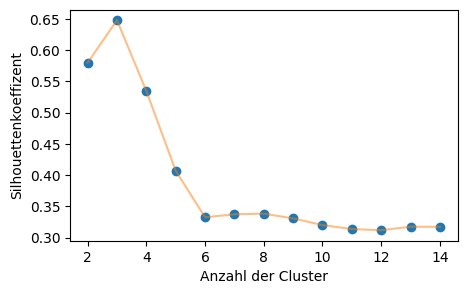

In [11]:
# Anwendung der Silhouetten-Methode:
# Der K-Means Algorithmus wird diesmal für 2 bis 15 Cluster ausgeführt (Hinweis: Die Methode silhouette_score ist erst ab 2 Clustern definiet). 
# Für jede Iteration wird der gemittelte Silhouettenkoeffizeint aller Datenpunkte berechnet und geplottet. Das Maximum drückt die optimale
# Anzahl an Clustern aus. Hierbei kann wieder $K=3$ bestätigt werden.
X1 = df[['headache' , 'melalgia']].values
s_scores = []
for n in range(2 , 15):
    algorithm = (KMeans(n_clusters = n, 
                        init='random', 
                        n_init = 1 ,
                        max_iter=300, 
                        tol=0.0001,  
                        random_state= 111 , 
                        algorithm='lloyd') )
    algorithm.fit(X1)
    # Berechne den durchschnittlichen Silhouettenkoeffizienten für alle Datenpunkte
    mss = silhouette_score(X1, algorithm.labels_)
    s_scores.append(mss)

plt.figure(1 , figsize = (5 ,3))
plt.plot(np.arange(2 , 15) , s_scores , 'o')
plt.plot(np.arange(2 , 15) , s_scores , '-' , alpha = 0.5)
plt.xlabel('Anzahl der Cluster') , plt.ylabel('Silhouettenkoeffizent')
plt.show()

## Schritt 5: Anwendung des K-Means
---
In diesem Schritt wird der K-Means Algorithmus auf den Datensatz mit $K=3$ angewandt. Den K-Means gibt es in mehreren Varianten.
Der bekannteste ist **Lloyd's Algorithmus**, der im folgenden Anwendung findet. Hierfür werden folgende Schritte angewandt:

1. Wahle die Anzahl der Cluster $K$.
2. Wähle zufällig $K$ Clusterzentren aus dem gegebenen Datensatz.
3. Berechne die Abstände zwischen den Datenpunkten und den Clusterzentren.
4. Ordne jeden Datepunkt dem nähersten Cluster zu.
5. Berechne neue Clusterzentren als Mittelwert der zugeordneten Datenpunkte
6. Wiederhole Schritte 3-5 bis die Clusterzentren ihre Position nicht verändern.



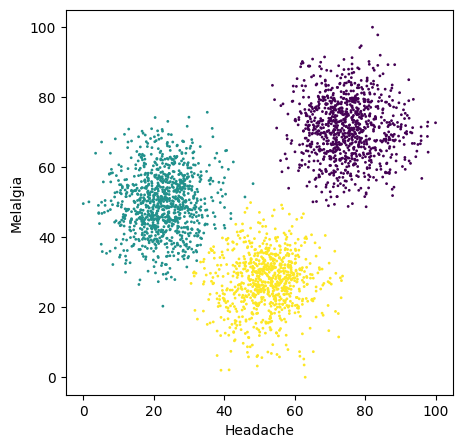

In [12]:
# Vorerst findet die Anwendung über die Klasse "K-Means" der Bibliothek scikit-learn statt. Somit ist eine Implementierung des oben genannten Algorithmus nicht notwendig.
# Nähere Informationen zu dieser Klasse gibt es hier: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
# Um jedoch die Anwendung nachvollziehen zu können, werden im folgenden die Parameter definiert:
# n_cluster: Definiert die Anzahl der zu berechnenden Cluster K. Wie zuvor ermittelt, ist dieser Wert in unserem Beispiel K=3.
# init: Definiert wie die Clusterzentren ausgesucht werden. Entweder passiert dies rein zufällig über den Wert "random" oder durch den K-Means++ Algorithmus über den Wert "k-means++".
#   In unserem Beispiel ist eine zufällige Wahl komplett ausreichend. In einem späteren Beispiel werden wir aber sehen, dass eine zufällige Initialisierung zu unterschiedliche
#   Ergebnissen führen kann.
# n_init: Gibt an wie oft der K-Means mit unterschiedlichen initialen Clusterzentren ausgeführt werden soll. Das wie zuvor erwähnt, das Ergebniss von der Wahl der initialen
#   Clusterzentren abhängen kann, muss sichergestellt werden, dass bei einer zufälligen Initialisierung, das optimalste Ergebniss berechnet wird. Hierfür wird der K-Means mehrmals ausgeführt
#   und das Ergebnis mit der geringsten "Within Cluster Sum of Squares (WCSS)" wird genommen. Dieser Wert spielt jedoch nur eine Rolle, wenn init="random".
# max_iter: Gibt an, wie viele Iterationen der K-Means durch laufen soll. Hierbei beziehen sich die Iterationen auf die Schritte 3-5 aus dem oben gezeigten Algorithmus. Sollte der
#   Algorithmus nach "max_iter" Iterationen nicht konvergieren, dann wird der Algorithmus vorzeitig beendet.
# tol: Gibt an, ob the Veränderung der Clusterzentren zwischen zwei Iterationen zur Konvergenz führt oder nicht. Ein Wert von 0 bspw. bedeutet, dass sich die Positionen der Zentren.
#   zwischen zwei Iterationen überhaupt nicht verändern darf. Die Veränderung wird über die Frobeniusnorm der Differenzen der Positionen zwischen zwei Iterationen berechnet.
# random_state: Bestimmt den Zufall bei der Initialisierung der Clusterzentren. Durch setzen eines Integers ist die Initialisierung deterministisch.
# algorithm: Gibt an welcher Variation des K-Means verwendet werden soll. Zur Auswahl stehen "lloyd" und "elkan". In diesem Beispiel wird nur ersteres behandelt.
algorithm = KMeans(n_clusters = 3,
                   init='random', 
                   n_init = 1,
                   max_iter=300, 
                   tol=0.0001, 
                   random_state=42, 
                   algorithm='lloyd')

algorithm.fit(X1)
labels1 = algorithm.labels_
centroids1 = algorithm.cluster_centers_

plt.figure(1 , figsize = (5 , 5) )
# Plotte die Datenpunkte mit Farben entsprechend ihrer Clusterzugehörigkeit
plt.scatter(x = X1[:,0], y = X1[:,1], c = labels1, s = 1)
# Zeichen Clusterzentren als rote Punkte
#plt.scatter(x = centroids1[: , 0] , y =  centroids1[: , 1] , s = 20 , c = 'red' , alpha = 1.0)
#plt.ylabel('Intensität Gliederschmerzen') , plt.xlabel('Intensität Kopfschmerzen')
plt.ylabel('Melalgia') , plt.xlabel('Headache')
plt.show()

## Schritt 6: Anwendung K-Means (Interaktiv)
---
Um ein besseres Gefühl für den Ablauf des K-Mean Algorithmuses zu bekommen, ist es nun möglich die Parameter zu justieren und sich zeitgleich das Ergebniss anzeigen zu lassen. Diese interaktive Umgebung soll helfen, die entsprechenden Übungsaufgaben im Moodle zu lösen.

In [13]:
WidgetsKMeans(data=X1)


interactive(children=(IntSlider(value=3, continuous_update=False, description='Number of Clusters', max=10, mi…

## Schritt 7: Umgang mit unnormierten Daten
---
In den obigen Beispielen bewegten sich beide Features in der selben Range:
$$
x\in [0,100]\times[0,100]
$$
Jedoch kann es nach Beschaffenheit der Daten dazu kommen, dass die Features stark voneinander abweichende Definitionsbereiche haben. Der hier betrachtete Datensatz hat folgende Range:
$$
x\in [0,1000]\times[0,1]
$$
Dieser Unterschied kann beim Clustering zu fehlerhaften Ergebnissen führen. Deshalb müssen die Daten vorher normalisiert werden.


In [14]:
# Angabe des relativen Pfades der CSV-Datei
input_file_2 = "datasets/krankheitscluster_unnormiert.csv"
# Erstellung des DataFrames; Hierbei wird Zeile 0 durch die Angabe "header = 0" als Zeile definiert, 
# die die Featurenamen und den Anfang der Daten angibt
df_2 = pd.read_csv(input_file_2, header = 0)
# Gibt die ersten n Datenpunkte des DataFrames zurück
df_2.head(n=5)

,Unnamed: 0,headache,melalgia,class
0,0,43.0,0.491,0
1,1,208.0,0.507,0
2,2,70.0,0.475,0
3,3,153.0,0.540,0
4,4,170.0,0.502,0


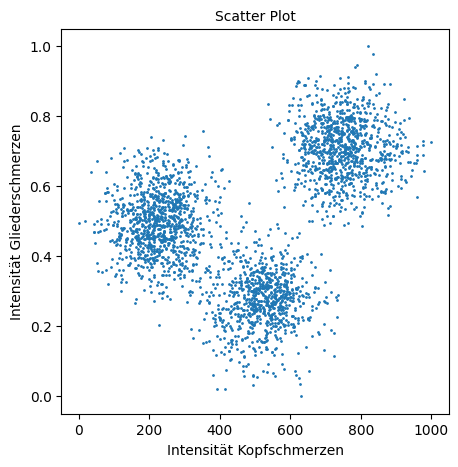

In [15]:
# Nun erzeugen wir ein Streudiagramm (engl. Scatter Plot) der ausgewählten Features und benennen entsprechend die Axen.
plt.figure(1 , figsize = (5 , 5))
plt.title('Scatter Plot', fontsize = 10)
plt.xlabel('Intensität Kopfschmerzen')
plt.ylabel('Intensität Gliederschmerzen')
plt.scatter( x = 'headache', y = 'melalgia', data = df_2, s = 1)
plt.show()

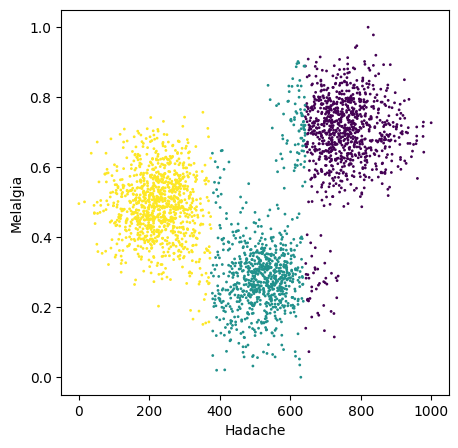

In [16]:
X2 = df_2[['headache' , 'melalgia']].iloc[: , :].values
algorithm_2 = KMeans(n_clusters = 3,
                   init='random', 
                   n_init = 1,
                   max_iter=300, 
                   tol=0.0001, 
                   random_state=42, 
                   algorithm='lloyd')

algorithm_2.fit(X2)
labels_2 = algorithm_2.labels_
centroids_2 = algorithm_2.cluster_centers_

plt.figure(1 , figsize = (5 , 5) )
# Plotte die Datenpunkte mit Farben entsprechend ihrer Clusterzugehörigkeit
plt.scatter(x = X2[:,0], y = X2[:,1], c = labels_2, s = 1)
#plt.ylabel('Intensität Gliederschmerzen') , plt.xlabel('Intensität Kopfschmerzen')
plt.ylabel('Melalgia') , plt.xlabel('Hadache')
plt.show()

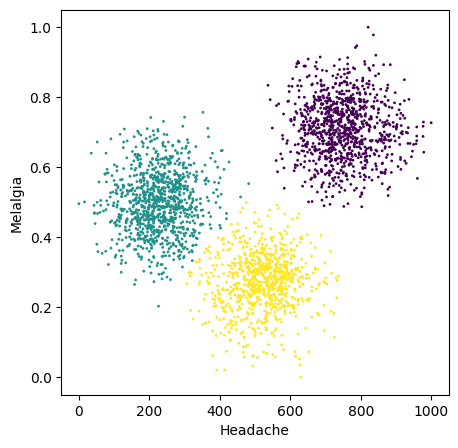

In [17]:
X3 = df_2[['headache' , 'melalgia']].iloc[: , :].values

X3_norm = normalize( X3, axis=0, norm="l2")

algorithm_3 = KMeans(n_clusters = 3,
                   init='random', 
                   n_init = 1,
                   max_iter=300, 
                   tol=0.0001, 
                   random_state=42, 
                   algorithm='lloyd')

algorithm_3.fit(X3_norm)
labels_3 = algorithm_3.labels_
centroids_3 = algorithm_3.cluster_centers_

plt.figure(1 , figsize = (5 , 5) )
# Plotte die Datenpunkte mit Farben entsprechend ihrer Clusterzugehörigkeit
plt.scatter(x = X3[:,0], y = X3[:,1], c = labels_3, s = 1)
#plt.ylabel('Intensität Gliederschmerzen') , plt.xlabel('Intensität Kopfschmerzen')
plt.ylabel('Melalgia') , plt.xlabel('Headache')
plt.show()

## Schritt 8: Evaluation
---
Um die Güte der Clusteringergebnisse zu bewerten, gibt es prinzipiell zwei große Kategorien von Methoden:
</br></br>
**Externe Gütemaße**:</br>
In diesem Fall liegt ein Vergleichsclustering, d.h. Groundtruth, vor, das für die Bewertung genutzt werden kann. Ein Beispiel für solch ein Gütemaß ist der Rand-Index (RI). Zur Erinnerung: Der RI kann Werte zwischen 0 und 1 annehmen, wobei ein Wert von 1 eine perfekte Übereinstimmung zwischen dem Clustering-Ergebnis und der wahren Klassenzuordnung anzeigt, ein Wert nahe 0 auf eine zufällige Klassenzuordnung hinweist. Der Rand-Index wird durch den Vergleich von Paaren von Datenpunkten zwischen zwei Clustering-Ergebnissen berechnet. Folgende Formel wird hierfür verwendet:
$$RI=\dfrac{a+b}{a+b+c+d}=\dfrac{a+b}{\binom{n}{2}}$$
Die Parameter in der obigen Gleichung sind wie folgt definiert:</br>
- $a$, die Anzahl an Paaren von Elementen in $S$, die in der **selben** Partition in $X$ und in der **selben** Partition in $Y$ sind.
- $b$, die Anzahl an Paaren von Elementen in $S$, die in **unterschiedlichen** Partition in $X$ und in **unterschiedlichen** Partition in $Y$ sind.
- $c$, die Anzahl an Paaren von Elementen in $S$, die in der **selben** Partition in $X$ und in **unterschiedlichen** Partition in $Y$ sind.
- $d$, die Anzahl an Paaren von Elementen in $S$, die in **unterschiedlichen** Partition in $X$ und in der **selben** Partition in $Y$ sind.

**Interne Gütemaße**:</br>
Liegt kein Clustering vor, das als Vergleich herangezogen werden kann, muss die Güte des Clusteringergebnisses anhand interner Eigenschaften bestimmt werden. Das hier betrachtete Gütemaß wurde bereits in Schritt 4 behandelt, und zwar der Silhouettenkoeffzient. Er misst, wie gut die Datenpunkte innerhalb eines Clusters zusammenpassen und wie gut sie von den Datenpunkten in anderen Clustern unterschieden werden können. Ein höherer Silhouettenkoeffizient deutet auf eine bessere Trennung und Konsistenz der Cluster hin. Der Silhouettenkoeffizient wird für jeden Datenpunkt einzeln berechnet und kann Werte zwischen -1 und 1 annehmen. Ein Wert von 1 zeigt an, dass der Datenpunkt gut zu seinem eigenen Cluster passt und gut von den Datenpunkten in anderen Clustern unterschieden werden kann. Ein Wert nahe 0 zeigt an, dass der Datenpunkt nahe an der Trennlinie zwischen zwei Clustern liegt. Ein Wert nahe -1 deutet darauf hin, dass der Datenpunkt möglicherweise im falschen Cluster platziert wurde. Der Koeffizient wird für jeden Datenpunkt einzeln berechnet:
$$s(i)=\dfrac{b(i) - a(i)}{\max(a(i), b(i))},~\textrm{if}~|C_I|>1$$
$$s(i)=0,~\textrm{if}~|C_I|=1$$
und dann aufsummiert:
$$S=\dfrac{1}{|D|}\sum_{i\in D}s(i)$$
Die Parameter sind wie folgt definiert:
$$a(i)=\dfrac{1}{|C_I|-1}\sum_{j\in C_I,i\neq j}d(i,j)$$
$$b(i)=\min_{J\neq I}\dfrac{1}{|C_J|}\sum_{j\in C_J}d(i,j)$$

In [18]:
# Berechnung der Güte der Clusteringergebnisse des normierten und unnormierten Datensatzes
# Die Berechnung des Rand Index erfolgt über die Clusterzuweisungen aus der entsprechenden Datei.

gt = df_2[['class']].iloc[: , :].values.reshape(-1)
ri_unnorm = rand_score(labels_2, gt)
ri_norm = rand_score(labels_3, gt)
print(ri_unnorm)
print(ri_norm)

0.9238784697893984
0.9899066627061239


0.6468409193192847
0.6475552296804926
[0.61686639 0.7438224  0.63740135 ... 0.52269291 0.55748633 0.59077829]


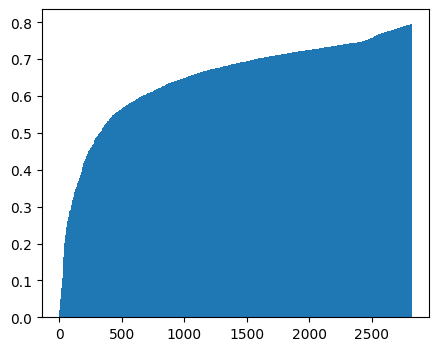

In [19]:
# Berechnung des Silhouettenkoeffizienten
s_score_unnorm = silhouette_score(X2, labels_2)
s_score_norm = silhouette_score(X3_norm, labels_3)
s_score_samples = silhouette_samples(X3_norm, labels_3)

print(s_score_unnorm)
print(s_score_norm)
print(s_score_samples)

fig = plt.figure(1 , figsize = (5 , 4) )
idd = range(s_score_samples.shape[0])
#print(s_score_samples.shape)
#print(idd[-1])
s_score_samples_sort = np.sort(s_score_samples)
#s_score_samples_sort = np.flip(s_score_samples_sort)
plt.bar(idd, s_score_samples_sort, width=1.0)
plt.show()

## Schritt 9: Umgang mit nicht-spährischen Clustern
---
Bisher wurden nur Datensätze mit spährischen Clustern betrachtet. Datensätze mit dieser Natur lassen sich sehr gut mit dem K-Means clustern. Datensätze mit Clustern, die Ringförmige strukturen aufweisen, sind über den K-Means nicht gruppierbar. Hierfür muss ein anderes Verfahren hinzugezogen werden. Ein bereits bekanntes Verfahren ist das Agglomerative Hierarchische Clustering. Ausgehend davon, dass jeder Datenpunkt ein eigenes Cluster dargstellt, werden bei dieser Methode iterativ die nährsten beiden Cluster zusammengefasst bis nur noch ein Cluster übrig bleibt. Visualisieren lässt sich das durch das Dendogram.

In [20]:
# Angabe des relativen Pfades der CSV-Datei
input_file_2 = "datasets/circular_data.csv"
# Erstellung des DataFrames; Hierbei wird Zeile 0 durch die Angabe "header = 0" als Zeile definiert, 
# die die Featurenamen und den Anfang der Daten angibt
df_4 = pd.read_csv(input_file_2, header = 0)
# Gibt die ersten n Datenpunkte des DataFrames zurück
df_4.head(n=5)

,Class,x,y
0,C1,0.496114,0.572293
1,C1,0.478327,0.624759
2,C1,0.463795,0.600542
3,C1,0.501587,0.591477
4,C1,0.474229,0.602816


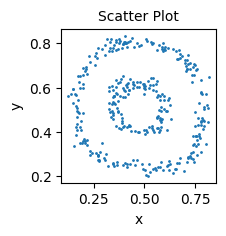

In [21]:
# Nun erzeugen wir ein Streudiagramm (engl. Scatter Plot) der ausgewählten Features und benennen entsprechend die Axen.
plt.figure(1 , figsize = (2 , 2))
plt.title('Scatter Plot', fontsize = 10)
plt.xlabel('x')
plt.ylabel('y')
plt.scatter( x = 'x', y = 'y', data = df_4, s = 1)
plt.show()

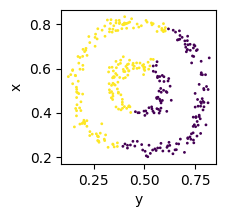

In [22]:
# Anwendung des K-Means auf nicht-spährische Daten
X4 = df_4[['x' , 'y']].iloc[: , :].values

algorithm_4 = KMeans(n_clusters = 2,
                   init='random', 
                   n_init = 1,
                   max_iter=300, 
                   tol=0.0001, 
                   random_state=42, 
                   algorithm='lloyd')

algorithm_4.fit(X4)
labels_4 = algorithm_4.labels_
centroids_4 = algorithm_4.cluster_centers_

plt.figure(1 , figsize = (2 , 2) )
# Plotte die Datenpunkte mit Farben entsprechend ihrer Clusterzugehörigkeit
plt.scatter(x = X4[:,0], y = X4[:,1], c = labels_4, s = 1)
plt.ylabel('x') , plt.xlabel('y')
plt.show()

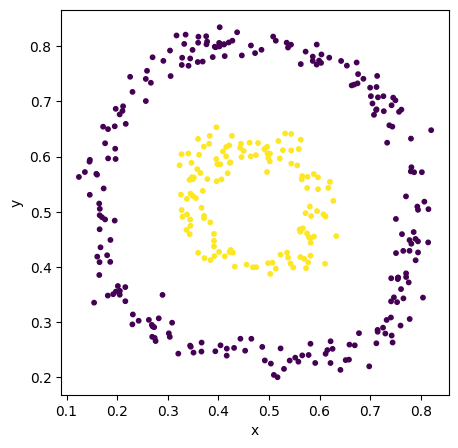

In [28]:
# Anwendung des Agglomerativen Hierarchischen Clusterings auf nicht-spährische Daten
algorithm_5 = AgglomerativeClustering(n_clusters=2, linkage="single", compute_distances=True)

algorithm_5.fit(X4)
labels_5 = algorithm_5.labels_

plt.figure(1 , figsize = (5 , 5) )
# Plotte die Datenpunkte mit Farben entsprechend ihrer Clusterzugehörigkeit
plt.scatter(x = X4[:,0], y = X4[:,1], c = labels_5, s = 5)
plt.ylabel('y')
plt.xlabel('x')
plt.show()

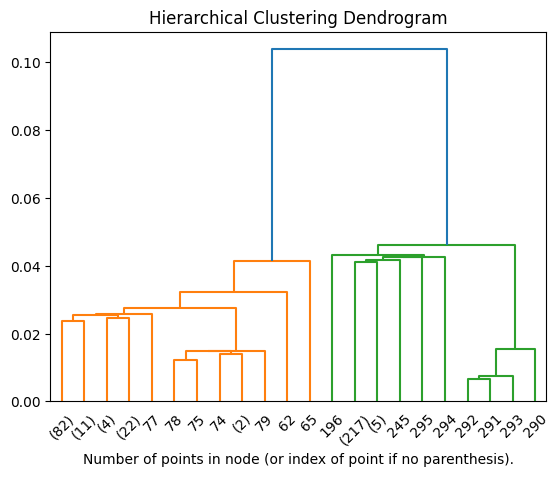

In [35]:
# Plotten des Dendograms
linkage_matrix = get_linkage_matrix(algorithm_5)
dendrogram(linkage_matrix,truncate_mode="level", p=6)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.show()